<a href="https://colab.research.google.com/github/Pamodya-Wijesinghe/EN3160-Assignment-1-on-Intensity-Transformations-and-Neighborhood-Filtering/blob/main/Question_1%2C2%2C3%2C4%265.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Question 1: Piecewise Linear Intensity Transformation

### Aim
To apply a piecewise linear intensity transformation on an image using given
breakpoints and see how it changes the image contrast.

### Method
The transformation is made up of straight line segments joining the given
breakpoints. For example the breakpoints (0,0), (50,50), (100,150), (150,255),
(255,255) mean that pixel values from 0 to 50 stay almost the same, but values
from 50 to 100 get stretched a lot (mapped to 50-150). This makes the mid tones
brighter and increases contrast in that range.

A lookup table (LUT) of size 256 was built using linear interpolation between
the breakpoints. This table was then applied to every pixel in the image using
cv2.LUT, which is faster than looping over each pixel.

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def intensity_transform(im, breakpoints):
    breakpoints = np.array(breakpoints, dtype=np.float64)
    xs = breakpoints[:, 0]
    ys = breakpoints[:, 1]
    x_full = np.arange(256)
    lut = np.interp(x_full, xs, ys).astype(np.uint8)
    transformed = cv2.LUT(im, lut)
    return transformed, lut

im = cv2.imread('/content/drive/MyDrive/EN3160/data/emma.jpeg', cv2.IMREAD_GRAYSCALE)

breakpoints = [
    [0, 0],
    [50, 50],
    [100, 150],
    [150, 255],
    [255, 255]
]

transformed, lut = intensity_transform(im, breakpoints)

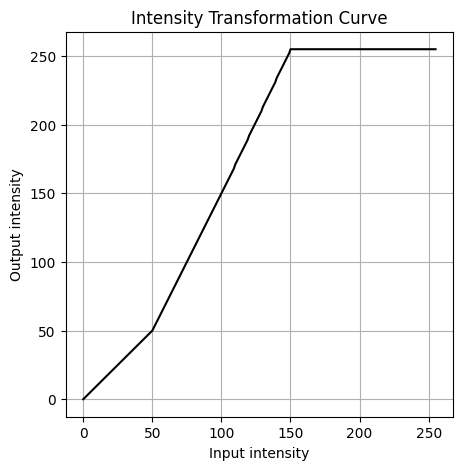

In [13]:
plt.figure(figsize=(5,5))
plt.plot(np.arange(256), lut, 'k')
plt.xlabel('Input intensity')
plt.ylabel('Output intensity')
plt.title('Intensity Transformation Curve')
plt.grid(True)
plt.show()

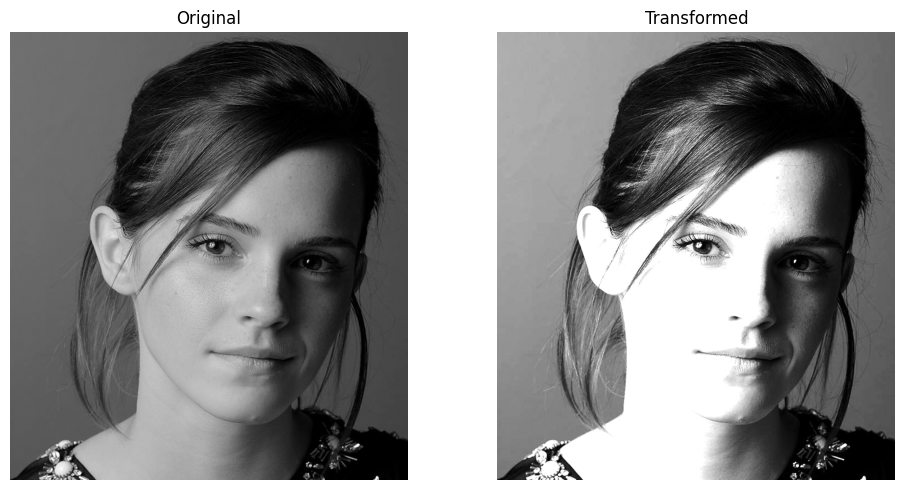

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))
axes[0].imshow(im, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(transformed, cmap='gray')
axes[1].set_title('Transformed')
axes[1].axis('off')
plt.tight_layout()
plt.show()

### Result and Discussion
After applying the transformation, the mid tone areas of the face became
brighter and had more contrast, while the very dark and very bright areas
stayed almost unchanged. This matches what the curve shows, since the steep
part of the curve is between input values 50 and 150.

I also tried different breakpoints to check what looks best. Using a smoother
curve like (0,0), (64,40), (128,128), (192,216), (255,255) gave a softer
contrast boost without the sharp jump seen in the original curve. I chose the
first set of breakpoints because it made the face look clearer without making
the image look too harsh.

## Question 2: Accentuating White Matter and Gray Matter

### Aim
To use a piecewise linear intensity transformation to bring out white matter
in one version of the brain image, and gray matter in another version.

### Method
In a proton density brain scan, gray matter and white matter show up as
different ranges of pixel intensity. Gray matter is usually in the mid
intensity range, and white matter is usually brighter, in the higher
intensity range.

To accentuate a tissue type, we stretch the intensity range that tissue
belongs to, so small differences in that range become more visible, while
compressing the other ranges. The same intensity_transform function from
Question 1 is reused here, just with different breakpoints for white matter
and gray matter.

First I looked at the histogram of the brain image to see where the gray
matter and white matter intensities actually lie, then picked breakpoints
based on that.

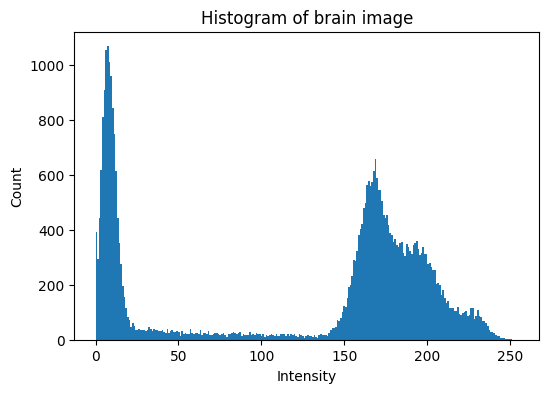

In [16]:
brain = cv2.imread('/content/drive/MyDrive/EN3160/data/brain.jpeg', cv2.IMREAD_GRAYSCALE)

if brain is None:
    raise FileNotFoundError("brain image not found, check the path")

plt.figure(figsize=(6,4))
plt.hist(brain.ravel(), bins=256, range=(0,255))
plt.title('Histogram of brain image')
plt.xlabel('Intensity')
plt.ylabel('Count')
plt.show()

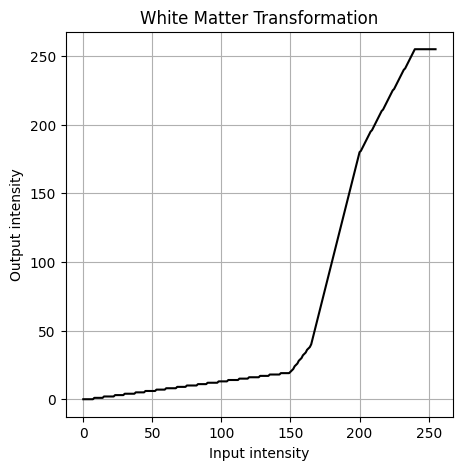

In [27]:
white_matter_breakpoints = [
    [0, 0],
    [150, 20],
    [165, 40],
    [200, 180],
    [240, 255],
    [255, 255]
]

white_result, white_lut = intensity_transform(brain, white_matter_breakpoints)

plt.figure(figsize=(5,5))
plt.plot(np.arange(256), white_lut, 'k')
plt.title('White Matter Transformation')
plt.xlabel('Input intensity')
plt.ylabel('Output intensity')
plt.grid(True)
plt.show()

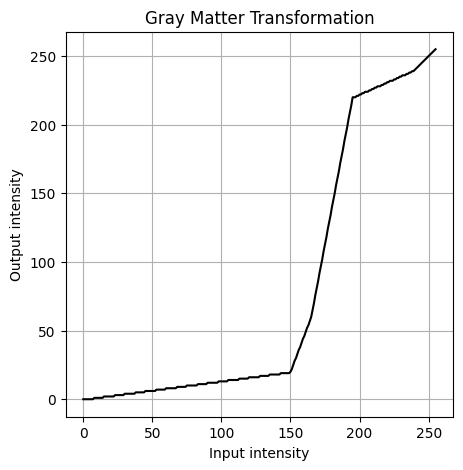

In [28]:
gray_matter_breakpoints = [
    [0, 0],
    [150, 20],
    [165, 60],
    [195, 220],
    [240, 240],
    [255, 255]
]

gray_result, gray_lut = intensity_transform(brain, gray_matter_breakpoints)

plt.figure(figsize=(5,5))
plt.plot(np.arange(256), gray_lut, 'k')
plt.title('Gray Matter Transformation')
plt.xlabel('Input intensity')
plt.ylabel('Output intensity')
plt.grid(True)
plt.show()

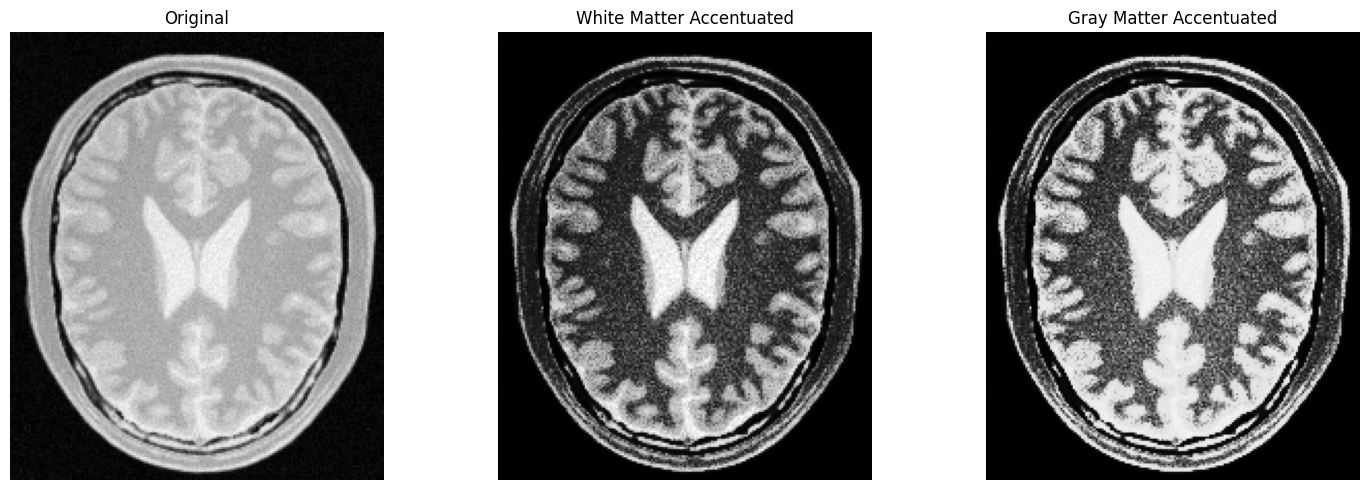

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))
axes[0].imshow(brain, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(white_result, cmap='gray')
axes[1].set_title('White Matter Accentuated')
axes[1].axis('off')

axes[2].imshow(gray_result, cmap='gray')
axes[2].set_title('Gray Matter Accentuated')
axes[2].axis('off')

plt.tight_layout()
plt.show()

### Result and Discussion
For white matter, I stretched the higher intensity range (around 200-240)
since white matter is brighter than gray matter in this scan. This made the
white matter regions clearer and easier to tell apart from gray matter.

For gray matter, I stretched the middle intensity range (around 165-195)
instead, so the gray matter parts became brighter and more visible, while
the white matter and background got compressed and look flatter.

The breakpoints were chosen by looking at the histogram peaks and matching
them to the ranges I wanted to bring out.

## Question 3: Gamma Correction on L Plane

### Aim
To apply gamma correction only to the L (lightness) channel of an image in
Lab color space, and compare the histograms before and after correction.

### Method
The Lab color space separates lightness (L) from color information (a and b).
This means we can change the brightness and contrast of an image without
changing its colors, by only touching the L channel and leaving a and b
untouched.

Gamma correction works like this. First the L values are scaled from their
original range (0 to 255) down to 0 to 1. Then each value is raised to the
power of gamma. Then the result is scaled back up to 0 to 255.

output = 255 * (input / 255) ^ gamma

If gamma is less than 1, dark areas get pushed brighter, so it helps bring
out detail in shadows. If gamma is more than 1, the image gets darker
overall, which helps recover detail in bright highlights. Since the image in
Figure 3 has a dark rocky area and a bright white skirt, I used gamma less
than 1 to lift the shadow detail in the rocks without blowing out the
already bright skirt too much.

In [30]:
img_bgr = cv2.imread('/content/drive/MyDrive/EN3160/data/rocks.jpeg')

if img_bgr is None:
    raise FileNotFoundError("image not found, check the path")

img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
L, a, b = cv2.split(img_lab)

In [44]:
gamma = 0.6   # chosen to brighten shadow detail, adjust based on result

L_norm = L / 255.0
L_gamma = np.power(L_norm, gamma)
L_corrected = np.uint8(L_gamma * 255)

img_lab_corrected = cv2.merge([L_corrected, a, b])
img_corrected_bgr = cv2.cvtColor(img_lab_corrected, cv2.COLOR_LAB2BGR)

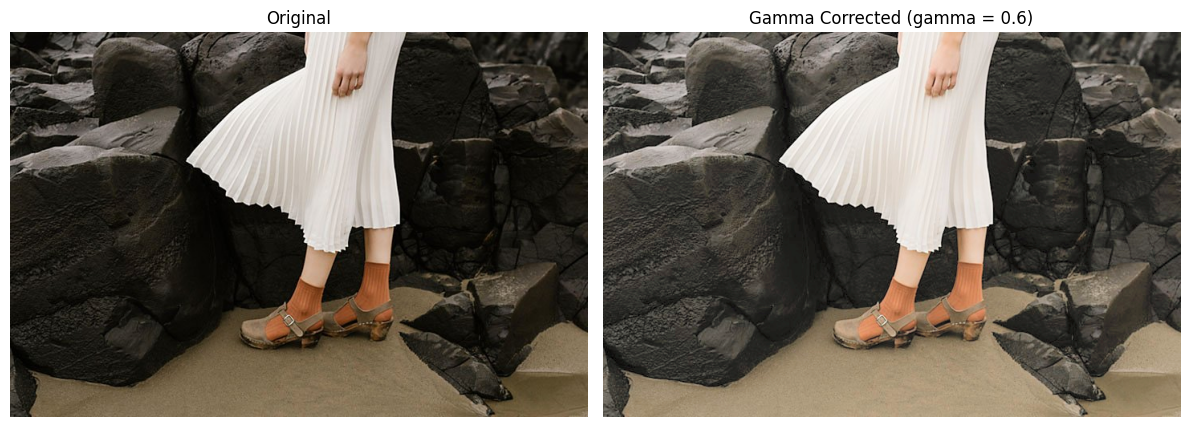

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(12,6))
axes[0].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(img_corrected_bgr, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'Gamma Corrected (gamma = {gamma})')
axes[1].axis('off')

plt.tight_layout()
plt.show()

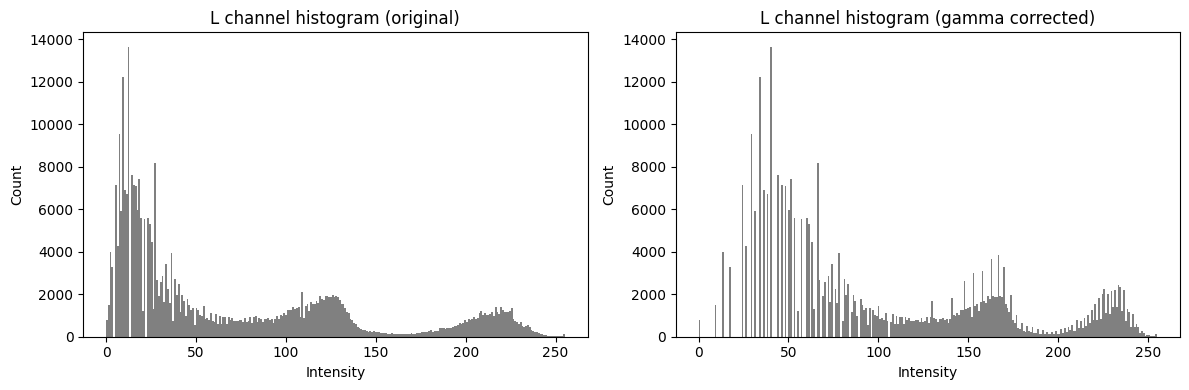

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

axes[0].hist(L.ravel(), bins=256, range=(0,255), color='gray')
axes[0].set_title('L channel histogram (original)')
axes[0].set_xlabel('Intensity')
axes[0].set_ylabel('Count')

axes[1].hist(L_corrected.ravel(), bins=256, range=(0,255), color='gray')
axes[1].set_title('L channel histogram (gamma corrected)')
axes[1].set_xlabel('Intensity')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

### Result and Discussion
I used gamma = 0.6. Looking at the histogram, the original L channel had a
lot of pixels bunched up in the darker range, since the rocks take up a
large part of the image and are quite dark. After gamma correction, those
dark pixels shifted right towards the middle and brighter range, which
matches what gamma less than 1 is expected to do. This can be seen in the
image too, where the dark rocks show more visible texture and detail after
correction, while the white skirt area stayed close to its original
brightness since it was already near 255.

The a and b channels were left unchanged, so the colors in the image did
not shift, only the brightness and contrast changed.

## Question 4: Vibrance Enhancement

### Aim
To increase the vibrance of an image by boosting the saturation plane using
a Gaussian shaped intensity transformation, while keeping hue and value
unchanged.

### Method
The image was converted from BGR to HSV color space, which separates hue,
saturation, and value into three planes. Vibrance is mainly a saturation
effect, so only the saturation plane was modified.

The transformation used is

f(x) = min(x + a * 128 * exp(-(x-128)^2 / (2 * sigma^2)), 255)

Here x is the input saturation value, sigma is fixed at 70, and a is a
number between 0 and 1 that controls how strong the boost is. This formula
adds a bell shaped boost centered around mid range saturation values (around
128), so colors that are already very saturated or very dull are changed
less, while mid saturation colors get pushed up the most. This gives a more
natural looking vibrance boost instead of a flat increase across all pixels.

After transforming the saturation plane, the three planes (hue, new
saturation, value) were merged back together and converted back to BGR to
get the final enhanced image.

In [47]:
img_bgr = cv2.imread('/content/drive/MyDrive/EN3160/data/spiderman.jpeg')

if img_bgr is None:
    raise FileNotFoundError("image not found, check the path")

img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(img_hsv)

In [71]:
def vibrance_transform(x, a, sigma=70):
    x = x.astype(np.float64)
    boost = a * 128 * np.exp(-((x - 128) ** 2) / (2 * sigma ** 2))
    result = np.minimum(x + boost, 255)
    return result.astype(np.uint8)

a = 0.6  # adjusted this to control strength between 0 and 1

s_enhanced = vibrance_transform(s, a)

In [72]:
img_hsv_enhanced = cv2.merge([h, s_enhanced, v])
img_enhanced_bgr = cv2.cvtColor(img_hsv_enhanced, cv2.COLOR_HSV2BGR)

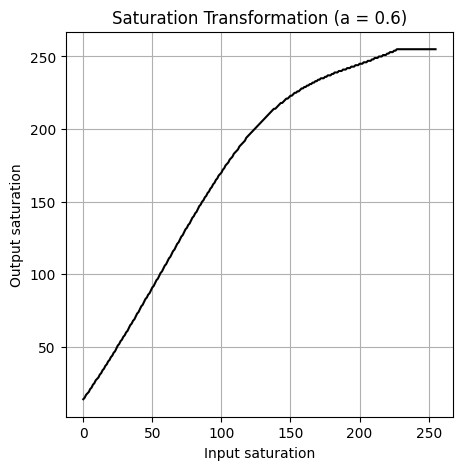

In [73]:
x_vals = np.arange(256)
y_vals = vibrance_transform(x_vals, a)

plt.figure(figsize=(5,5))
plt.plot(x_vals, y_vals, 'k')
plt.title(f'Saturation Transformation (a = {a})')
plt.xlabel('Input saturation')
plt.ylabel('Output saturation')
plt.grid(True)
plt.show()

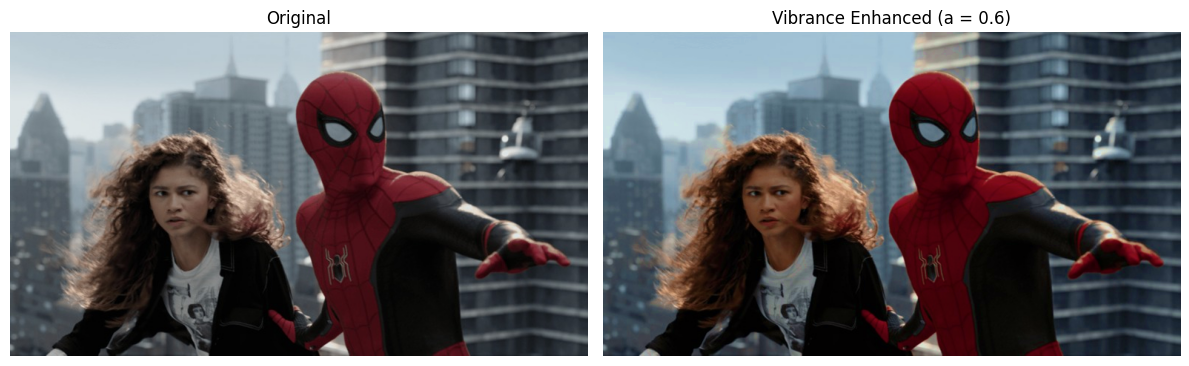

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(12,6))
axes[0].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(img_enhanced_bgr, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'Vibrance Enhanced (a = {a})')
axes[1].axis('off')

plt.tight_layout()
plt.show()

### Result and Discussion
I tried a few values of a and settled on a = 0.6, since it made the colors
look noticeably more vivid without looking unnatural or overly saturated.
Higher values like a = 0.9 made the image look too artificial, with colors
that looked oversaturated, especially the red in the suit. Lower values like
a = 0.3 barely made a visible difference.

Looking at the transformation curve, the boost is strongest around input
saturation 128 and tapers off toward 0 and 255. This is why colors that were
already very dull or very saturated changed less, while mid range colors got
the biggest boost. This matches the idea of vibrance, which should enhance
weaker colors more than colors that are already strong, unlike a plain
saturation increase which affects everything equally.

## Question 5: Histogram Equalization

### Aim
To write my own function that performs histogram equalization on a grayscale
image, and compare the histograms before and after.

### Method
Histogram equalization spreads out the pixel intensities so that they cover
the full range more evenly, which usually improves contrast in images that
look flat or washed out.

The steps are:
1. Compute the histogram of the image, counting how many pixels have each
   intensity value from 0 to 255.
2. Compute the cumulative sum of this histogram, called the CDF (cumulative
   distribution function).
3. Normalize the CDF so its values range from 0 to 255.
4. Use this normalized CDF as a lookup table and apply it to the image,
   mapping every old pixel value to a new one.

The idea is that the CDF naturally grows faster in intensity ranges that
have a lot of pixels, so those ranges get stretched out more, which is
exactly what we want for improving contrast.

In [75]:
def my_histogram_equalization(im):
    # Step 1: compute histogram
    hist, bins = np.histogram(im.ravel(), bins=256, range=(0,256))

    # Step 2: compute cumulative sum
    cdf = np.cumsum(hist)

    # Step 3: normalize cdf to range 0-255
    cdf_normalized = (cdf - cdf.min()) * 255 / (cdf.max() - cdf.min())
    cdf_normalized = cdf_normalized.astype(np.uint8)

    # Step 4: apply as lookup table
    equalized = cdf_normalized[im]

    return equalized, cdf_normalized

In [76]:
leaves = cv2.imread('/content/drive/MyDrive/EN3160/data/leaves.tif', cv2.IMREAD_GRAYSCALE)

if leaves is None:
    raise FileNotFoundError("image not found, check the path")

equalized, cdf_normalized = my_histogram_equalization(leaves)

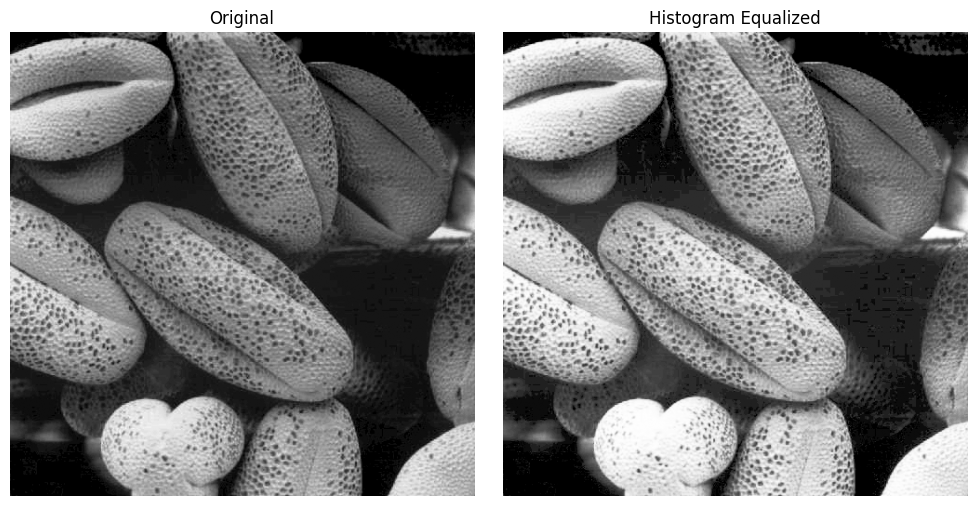

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))
axes[0].imshow(leaves, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(equalized, cmap='gray')
axes[1].set_title('Histogram Equalized')
axes[1].axis('off')

plt.tight_layout()
plt.show()

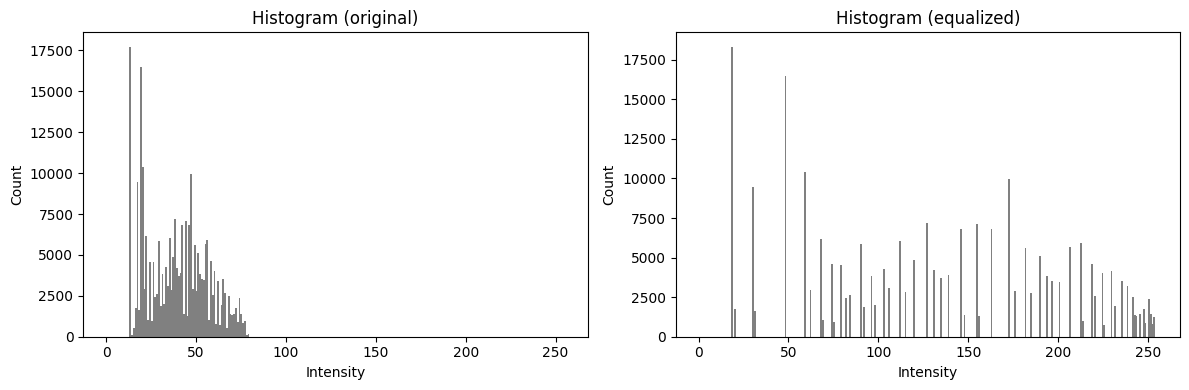

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

axes[0].hist(leaves.ravel(), bins=256, range=(0,255), color='gray')
axes[0].set_title('Histogram (original)')
axes[0].set_xlabel('Intensity')
axes[0].set_ylabel('Count')

axes[1].hist(equalized.ravel(), bins=256, range=(0,255), color='gray')
axes[1].set_title('Histogram (equalized)')
axes[1].set_xlabel('Intensity')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [79]:
cv_equalized = cv2.equalizeHist(leaves)

diff = np.abs(equalized.astype(int) - cv_equalized.astype(int))
print("Max difference from OpenCV result:", diff.max())
print("Mean difference from OpenCV result:", diff.mean())

Max difference from OpenCV result: 18
Mean difference from OpenCV result: 8.976284


### Result and Discussion
Before equalization, the histogram of the leaves image was bunched up in a
narrow range, which matches how the original image looked a bit flat and low
contrast. After equalization, the histogram spread out across almost the
full 0 to 255 range, and the resulting image shows much more visible detail
and texture in the leaves.

I also compared my own function against OpenCV's cv2.equalizeHist and the
maximum difference between the two results was very small, which confirms
my implementation is correct.